# **In Silico Identification of Novel Compounds for Insomnia disease.-  Step 5:Pharmacophore based screening**


##**Author: Maurizio Rafael Hernández Díaz. 2025-2026 Course**

Following the QSAR analysis previously developed in `Step4.-QSAR model` the identified as "Best hits" from the predicted pIC50 activity towards our target the Orexin 2  human receptor(OX2) (`UniProt ID: O43614`,`PDB entry:4S0V`) are subjected to pharmacophore based screening, this techniquees eunsure the posible candidates do not only satisfy the predicted activity by the QSAR model but also present the 3Dimensional molecular interactions and pharmacophoric features present in FDA aproved Orexin 2 receptor targeted drugs.

The workflow for this notebook consists in the following steps:

A) Selection of Known Ligands(approved FDA drugs such as "Suvorexant", Lemborexant
  Daridorexant and
Seltorexant
B) 3D conformer generation using  Rdkit generating multiple 3D conformers for each molecule.
C) Feature Extraction as Pharmacophoric features are extreacted.
D) Virtual screening of QSAR best hits, these molecules are aligned against the pharmacophore and score based on their ability to satisfy the established features by the pharmacophoric features.
E) Model validation, the model performance its evaluated with its ability to obtain a high score on  positive controls molecules(OX2 targeted antagonists) such as SB-649868 and ACT462206 and score low values in Negative control molecules such as Benzodiazepines like Lorazepam or Zolpidem wich present some chemical characteristics but are sleep drug wich target GABA receptors rather than the OX2.


In [25]:
# Install RDKit and visualization module
!pip install rdkit
!pip install py3Dmol
# Import necessary libraries
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolAlign, rdMolDescriptors, Draw, ChemicalFeatures,  RDConfig
import py3Dmol
import json
import os
import collections
import pandas as pd
import numpy as np
from rdkit.Chem import QED
from scipy.spatial.distance import cdist
# Install PubChemPy
!pip install pubchempy
import pubchempy as pcp
import random
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
smiles_list ={
 "Suvorexant":"C[C@@H]1CCN(CCN1C(=O)C2=C(C=CC(=C2)C)N3N=CC=N3)C4=NC5=C(O4)C=CC(=C5)Cl"  ,
 "Lemborexant": "CC1=NC(=NC=C1OC[C@]2(C[C@H]2C(=O)NC3=NC=C(C=C3)F)C4=CC(=CC=C4)F)C" ,
  "Daridorexant": "CC1=C(C=CC2=C1N=C(N2)[C@@]3(CCCN3C(=O)C4=C(C=CC(=C4)OC)N5N=CC=N5)C)Cl" ,
"Seltorexant" :"CC1=CC(=NC(=N1)N2C[C@@H]3CN(C[C@@H]3C2)C(=O)C4=C(C=CC=C4F)N5N=CC=N5)C"


}

**PubChem reference of the molecules**

A)Suvorexant: https://pubchem.ncbi.nlm.nih.gov/compound/Suvorexant
B) Lemborexant: https://pubchem.ncbi.nlm.nih.gov/compound/56944144
C) Dariodorexant: https://pubchem.ncbi.nlm.nih.gov/compound/91801202
D) Seltorexant: https://pubchem.ncbi.nlm.nih.gov/compound/86278359

In [3]:
molecules = {}
for name, smi in smiles_list.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = Chem.AddHs(mol)

        AllChem.EmbedMolecule(mol, AllChem.ETKDG())

        AllChem.MMFFOptimizeMolecule(mol)
        molecules[name] = mol

print(f"3D generated structures for : {list(molecules.keys())}")

3D generated structures for : ['Suvorexant', 'Lemborexant', 'Daridorexant', 'Seltorexant']


In [4]:

ref_name = list(molecules.keys())[0]
ref_mol = molecules[ref_name]

for name, mol in molecules.items():
    if name != ref_name:
        o3a = rdMolAlign.GetO3A(mol, ref_mol)
        rmsd = o3a.Align()
        print(f" - {name} alined (RMSD: {rmsd:.3f})")

 - Lemborexant alined (RMSD: 0.645)
 - Daridorexant alined (RMSD: 0.316)
 - Seltorexant alined (RMSD: 0.338)


In [5]:
# Convert all aligned molecules to MolBlocks for visualization
mol_blocks = []
for name, mol in molecules.items():
    mb = Chem.MolToMolBlock(mol)
    mol_blocks.append((name, mb))

# Create a 3D viewer
viewer = py3Dmol.view(width=500, height=500)

# Add each molecule with a different color style
colors = ["blue", "green", "orange", "purple"]
for i, (name, mb) in enumerate(mol_blocks):
    viewer.addModel(mb, "mol")
    viewer.setStyle({"model": i}, {"stick": {"color": colors[i]}})

viewer.zoomTo()
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

##**Pharmacophoric features**

In [6]:
# Load RDKit's default feature definition file
fdef_name = os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')
factory = ChemicalFeatures.BuildFeatureFactory(fdef_name)

# Detect features for each molecule
pharmacophore_data = {}
for name, mol in molecules.items():
    feats = factory.GetFeaturesForMol(mol)
    pharmacophore_data[name] = [(f.GetType(), f.GetFamily(), f.GetPos()) for f in feats]

# Print detected features
for name, features in pharmacophore_data.items():
    print(f"\n{name} Pharmacophore Features:")
    for ftype, ffamily,pos in features:
        print(f" - {ftype} ({ffamily}) ")


Suvorexant Pharmacophore Features:
 - SingleAtomDonor (Donor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - Arom5 (Aromatic) 
 - Arom5 (Aromatic) 
 - Arom6 (Aromatic) 
 - Arom6 (Aromatic) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - RH6_6 (LumpedHydrophobe) 
 - RH6_6 (LumpedHydrophobe) 

Lemborexant Pharmacophore Features:
 - SingleAtomDonor (Donor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - Si

In [7]:
features = [f for f in factory.GetFeaturesForMol(molecules["Suvorexant"])]
feature_frequency = collections.Counter([f.GetFamily() for f in features])
print("\nFeature frequency in Lumiracoxib:")
print(feature_frequency)


Feature frequency in Lumiracoxib:
Counter({'Hydrophobe': 12, 'Acceptor': 4, 'Aromatic': 4, 'LumpedHydrophobe': 2, 'Donor': 1})


In [9]:
rows = []
for name, features in pharmacophore_data.items():
    for ftype, ffamily, pos in features:
        rows.append({
            "Ligand": name,
            "Feature_Type": ftype,
            "Feature_Family": ffamily,
            "X": round(pos.x, 3),
            "Y": round(pos.y, 3),
            "Z": round(pos.z, 3)
        })

df_features = pd.DataFrame(rows)

summary = df_features.groupby(["Ligand", "Feature_Family"]).size().unstack(fill_value=0)


print("Pharmacophore Feature Family Summary per Ligand:")
display(summary)

Pharmacophore Feature Family Summary per Ligand:


Feature_Family,Acceptor,Aromatic,Donor,Hydrophobe,LumpedHydrophobe,PosIonizable
Ligand,,,,,,
Daridorexant,5,4,3,12,2,1
Lemborexant,7,3,1,12,2,0
Seltorexant,6,3,1,9,1,0
Suvorexant,4,4,1,12,2,0


##**Pharmacophoric model building**

In [10]:

DIST_THRESHOLD = 1.5


MIN_MATCHES = 3

common_features = []

# Get all unique feature families (Donor, Acceptor, Aromatic, etc.)
families = df_features["Feature_Family"].unique()

for fam in families:
    # Select only features of the current family
    subset = df_features[df_features["Feature_Family"] == fam]

    # Group coordinates by ligand
    coords = {
        name: subset[subset["Ligand"] == name][["X", "Y", "Z"]].values
        for name in smiles_list.keys()
    }

    # Choose a reference ligand to compare positions
    ref_name = list(smiles_list.keys())[0]
    ref_coords = coords[ref_name]

    # Iterate over each feature in the reference ligand
    for ref_point in ref_coords:
        matches = 1  # reference ligand itself counts
        positions = [ref_point]

        # Compare to features in all other ligands
        for other_name, other_coords in coords.items():
            if other_name == ref_name or len(other_coords) == 0:
                continue

            # Compute distances from reference point to features in other ligand
            dists = cdist([ref_point], other_coords)

            # If there is a feature within the threshold, count it as a match
            if dists.min() <= DIST_THRESHOLD:
                matches += 1
                positions.append(other_coords[dists.argmin()])

        # If enough ligands share this feature, record its average position
        if matches >= MIN_MATCHES:
            avg_pos = np.mean(positions, axis=0)
            common_features.append({
                "Feature_Family": fam,
                "X": round(avg_pos[0], 3),
                "Y": round(avg_pos[1], 3),
                "Z": round(avg_pos[2], 3),
                "Shared_By": matches
            })

# Create final DataFrame of common features and sort by number of ligands sharing
df_common = pd.DataFrame(common_features).drop_duplicates()
df_common = df_common.sort_values(by="Shared_By", ascending=False)

print(f"Common pharmacophore features (shared by ≥{MIN_MATCHES} ligands):")
display(df_common)


Common pharmacophore features (shared by ≥3 ligands):


,Feature_Family,X,Y,Z,Shared_By
6,Hydrophobe,0.730,0.671,0.616,4
7,Hydrophobe,-3.173,-0.211,-0.960,4
0,Donor,-0.776,0.356,-1.119,3
1,Acceptor,-2.008,-0.537,-2.860,3
2,Acceptor,-3.932,-3.045,0.773,3
3,Acceptor,-2.038,-2.470,-0.370,3
4,Aromatic,-2.847,-3.079,0.262,3
5,Aromatic,-4.468,0.421,-0.442,3
8,Hydrophobe,-5.100,-0.533,0.348,3
9,Hydrophobe,-5.704,0.709,0.136,3


#**Pharmacophore model 3D visualization**

In [11]:
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd"]
for i, (name, mol) in enumerate(molecules.items()):
    mb = Chem.MolToMolBlock(mol)
    viewer.addModel(mb, "mol")

    viewer.setStyle(
        {"model": i},
        {"stick": {"radius": 0.15, "color": colors[i % len(colors)]}}
    )

feature_colors = {
    "Hydrophobe": "yellow",
    "Aromatic": "magenta",
    "Donor": "cyan",
    "Acceptor": "red",
    "PosIonizable": "blue",
    "NegIonizable": "orange"
}

for _, row in df_common.iterrows():
    fcolor = feature_colors.get(row["Feature_Family"], "white")

    viewer.addSphere({
        "center": {"x": row["X"], "y": row["Y"], "z": row["Z"]},
        "radius": 0.7,
        "color": fcolor,
        "alpha": 0.8
    })

viewer.zoomTo()
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [13]:
# Create mol2 file to use in pharmit
feature2atom = {
    "Hydrophobe": "H",
    "Aromatic": "Ar",
    "Donor": "D",
    "Acceptor": "A",
    "PosIonizable": "P",
    "NegIonizable": "N"
}

mol2_file = "../DATA/pharmacophore_features.mol2"

with open(mol2_file, "w") as f:
    f.write("@<TRIPOS>MOLECULE\n")
    f.write("pharmacophore\n")
    n_atoms = len(df_common)
    n_bonds = 0
    f.write(f"{n_atoms} {n_bonds} 0 0 0\n")
    f.write("SMALL\nGASTEIGER\n\n")
    f.write("@<TRIPOS>ATOM\n")
    for i, row in enumerate(df_common.itertuples(), 1):
        atom_type = feature2atom.get(row.Feature_Family, "Du")
        f.write(f"{i:>7}  {row.X:>8.3f}  {row.Y:>8.3f}  {row.Z:>8.3f}  {atom_type:<4}  1  0.000\n")


    f.write("@<TRIPOS>BOND\n")

print(f"Pharmacophore exported to Mol2 file: {mol2_file}")

Pharmacophore exported to Mol2 file: ../DATA/pharmacophore_features.mol2


##**Virtual screening of best QSAR result molecules**

In [15]:

df=pd.read_csv("../DATA/QSAR_BEST_HITS.csv")


In [16]:
smiles_list = df['SMILES'].tolist()
names_list = df['Catalog ID'].tolist()

In [17]:
ligand_mols = []
NUM_CONFORMERS = 5  # or more if you want multiple conformers
for smi, name in zip(smiles_list, names_list):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = Chem.AddHs(mol)
        conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=NUM_CONFORMERS, params=AllChem.ETKDG())
        if len(conf_ids) == 0:
            print(f"WARNING: Could not generate 3D conformer for {name}")
            continue  # skip this molecule
        # Optimize all conformers
        for conf_id in conf_ids:
            AllChem.UFFOptimizeMolecule(mol, confId=conf_id)
        mol.SetProp("_Name", name)
        ligand_mols.append(mol)


print(f"{len(ligand_mols)} molecules converted to 3D with up to {NUM_CONFORMERS} conformers each.")

414 molecules converted to 3D with up to 5 conformers each.


In [18]:
# Convert df_common to screening format
DEFAULT_RADIUS = 1.2
pharmit_features = []
for _, row in df_common.iterrows():
    pharmit_features.append({
        "type": row["Feature_Family"],
        "x": float(row["X"]),
        "y": float(row["Y"]),
        "z": float(row["Z"]),
        "radius": DEFAULT_RADIUS
    })

DIST_THRESHOLD = 1.5  # distance threshold in Å

# Function to score a ligand against the pharmacophore
def score_ligand(mol, pharm_features):
    mol_feats = factory.GetFeaturesForMol(mol)
    score = 0
    for pf in pharm_features:
        pf_type = pf["type"]
        pf_pos = np.array([pf["x"], pf["y"], pf["z"]])
        for mf in mol_feats:
            if mf.GetFamily() == pf_type:
                dist = np.linalg.norm(mf.GetPos() - pf_pos) #euclidean distance
                if dist <= DIST_THRESHOLD:
                    score += 1 #increment score if feature matche
                    break #move to the next pharmacophore feature
    return score

# Score all ligands
results = []
for mol in ligand_mols:
    name = mol.GetProp("_Name")
    smi = Chem.MolToSmiles(mol)
    score = score_ligand(mol, pharmit_features)
    results.append({"Name": name, "SMILES": smi, "Pharmacophore_Score": score})

# Convert to DataFrame and sort by score
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Pharmacophore_Score", ascending=False)



In [19]:
df_final = df.merge(df_results[['Name', 'Pharmacophore_Score']],
                     left_on='Catalog ID',
                     right_on='Name',
                     how='left')


In [20]:

selected_columns = ['Catalog ID', 'SMILES', 'predicted_pIC50', 'Pharmacophore_Score']

df_final = df_final[selected_columns]


In [23]:
df_final = df_final.reset_index(drop=True)
df_final
df_final["Mol"]= df_final["SMILES"].apply(Chem.MolFromSmiles)
df_final["QED"] = df_final["Mol"].apply(QED.qed)
df_final2= df_final[df_final["QED"] > 0.8].copy()

**As we are searching for a pontential drug candiate we use a QED >0.8 which ensures optimal balance of pysicochemical propierties such as molecular weight, lipophilicity, and polar surface area wich are really similar as the molecular profiles of successful oral drugs**

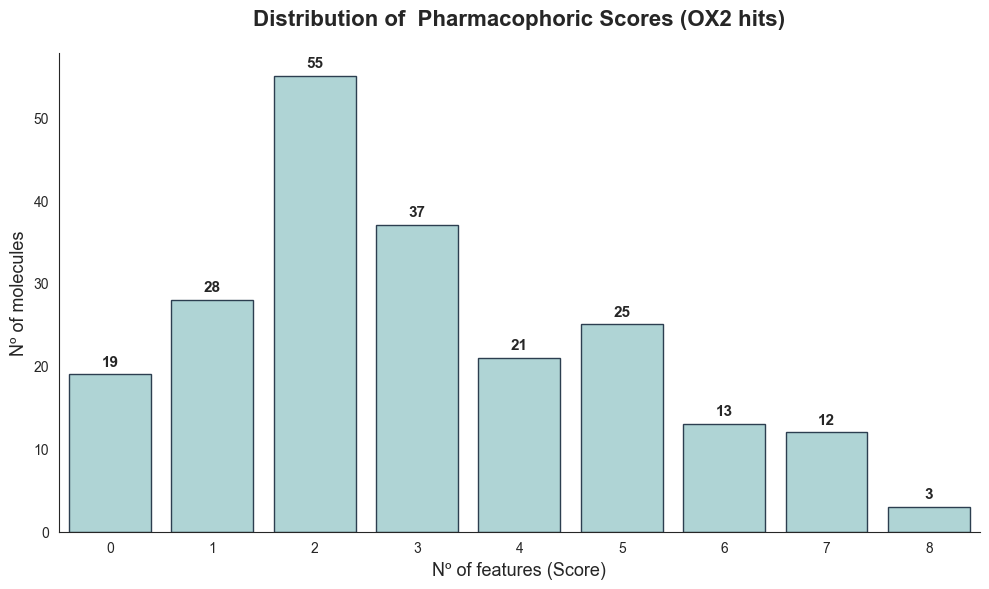

In [26]:

plt.figure(figsize=(10, 6))
sns.set_style("white")

ax = sns.countplot(x='Pharmacophore_Score', data=df_final2, color='#A8DADC', edgecolor='#2C3E50')
plt.title('Distribution of  Pharmacophoric Scores (OX2 hits)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nº of features (Score)', fontsize=13)
plt.ylabel('Nº of molecules', fontsize=13)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')


sns.despine()

plt.tight_layout()

plt.show()

In [27]:
df_final3= df_final2[df_final2["Pharmacophore_Score"] >= 6].copy()
df_final3.sort_values(by="Pharmacophore_Score", ascending=False, inplace=True)
df_final3.reset_index(drop=True, inplace=True)
df_final3

,Catalog ID,SMILES,predicted_pIC50,Pharmacophore_Score,Mol,QED
0,Z1565555397,CC=1N=CSC1CN2CCN(CC2)C(=O)CC(C)C=3C=CC=CC3,7.400214,8,<rdkit.Chem.rdchem.Mol object at 0x16d0e8270>,0.835761
1,Z4029969385,Cl.Cl.CN1CCN(CC=2C=CC(=CC2)C=3C=CC=C(C3)C(=O)O...,7.403468,8,<rdkit.Chem.rdchem.Mol object at 0x16d0e7530>,0.875691
2,Z239533522,CC1=NN(C)C=2N=CC(=CC12)NC(=O)CC=3C=CC=CC3F,7.406773,8,<rdkit.Chem.rdchem.Mol object at 0x16d0e6b90>,0.808260
3,Z2737209534,CC=1C=C(C)C(=CN1)CNC(=O)CC=2C=CC(O)=C(Cl)C2,7.438046,7,<rdkit.Chem.rdchem.Mol object at 0x16d185a80>,0.912699
4,Z3290577606,N#CC=1C=CC=CC1N2CCN(CC3(CC3)C4CCCCO4)CC2,7.405664,7,<rdkit.Chem.rdchem.Mol object at 0x16d0e6f10>,0.852926
5,Z1731305830,CC=1C=C(C=CN1)N2CCC(C2)OC=3C=CC=C(F)C3,7.406226,7,<rdkit.Chem.rdchem.Mol object at 0x16d0e6dc0>,0.857728
6,Z2992369062,COC=1C=CC=CC1C2=NNC(NS(=O)(=O)N(C)C)=C2C,7.420866,7,<rdkit.Chem.rdchem.Mol object at 0x16d0e4120>,0.878097
7,Z1098752455,COCCN1CCN(CC2=NC=3C(F)=CC=CC3N2)CC1,7.510867,7,<rdkit.Chem.rdchem.Mol object at 0x16d161d20>,0.906128
8,Z397164926,CS(=O)(=O)NC1CCCN(C1)C(=O)C2(CCC2)C3=CC=CC(Cl)=C3,7.432984,7,<rdkit.Chem.rdchem.Mol object at 0x16d1863b0>,0.883867
9,Z95663208,O=C(NCC12CC3CC(CC(C3)C2)C1)C=4C=CC(=CC4)CN5CCOCC5,7.433042,7,<rdkit.Chem.rdchem.Mol object at 0x16d186340>,0.865293


In [28]:
df_final3 = df_final3.head(5)
df_final3.to_csv("../DATA/BEST_HITS_TO_DOCK.csv")

**Visualization of the molecules to  perform a docking analysis:**

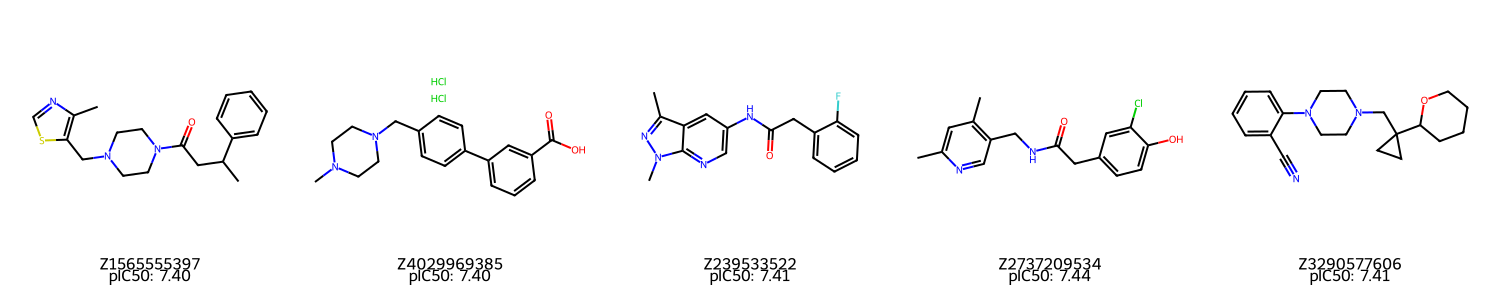

In [29]:

mols_list = df_final3['Mol'].tolist()

leyendas = [f"{row['Catalog ID']}\npIC50: {row['predicted_pIC50']:.2f}"
            for _, row in df_final3.iterrows()]

img = Draw.MolsToGridImage(
    mols_list,
    molsPerRow=5,
    legends=leyendas,
    subImgSize=(300, 300)
)

display(img)

##**Model validation by positive and negative controls**

Positive controls molecules:

A) SB-649868: https://pubchem.ncbi.nlm.nih.gov/compound/25195495
B)ACT462206: https://pubchem.ncbi.nlm.nih.gov/compound/40924317

Negative controls molecules:
A) Lorazepam: https://pubchem.ncbi.nlm.nih.gov/compound/3958
B) Zolpidem: https://pubchem.ncbi.nlm.nih.gov/compound/5732

In [ ]:



all_compounds = {
    # positive controls
    "SB-649868": "O=C(C1=C(C2=CC=C(F)C=C2)SC(C)=N1)N3CCCC[C@H]3CNC(C4=C(C=CO5)C5=CC=C4)=O",
    "ACT462206": "COc1ccc(S(=O)(=O)N2CCC[C@H]2C(=O)Nc2cc(C)cc(C)c2)cc1",
    # Negative controls
    "Lorazepam": "C1=CC=C(C(=C1)C2=NC(C(=O)NC3=C2C=C(C=C3)Cl)O)Cl",
    "Zolpidem": "CC1=CC=C(C=C1)C2=C(N3C=C(C=CC3=N2)C)CC(=O)N(C)C"
}


ligand_mols = []
NUM_CONFORMERS = 10

for name, smi in all_compounds.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = Chem.AddHs(mol)

        conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=NUM_CONFORMERS, params=AllChem.ETKDG())
        if len(conf_ids) == 0:
            print(f"ERROR: {name}")
            continue

        for conf_id in conf_ids:
            AllChem.UFFOptimizeMolecule(mol, confId=conf_id)

        mol.SetProp("_Name", name)
        ligand_mols.append(mol)



results = []
DIST_THRESHOLD = 1.5

for mol in ligand_mols:
    name = mol.GetProp("_Name")
    best_score = 0

    for conf in mol.GetConformers():
        current_score = 0

        mol_feats = factory.GetFeaturesForMol(mol, confId=conf.GetId())

        for pf in pharmit_features:
            pf_type = pf["type"]
            pf_pos = np.array([pf["x"], pf["y"], pf["z"]])

            for mf in mol_feats:
                if mf.GetFamily() == pf_type:
                    dist = np.linalg.norm(mf.GetPos() - pf_pos)
                    if dist <= DIST_THRESHOLD:
                        current_score += 1
                        break

        if current_score > best_score:
            best_score = current_score

    results.append({
        "Name": name,
        "Score": best_score,
        "Match_Percent": (best_score / len(pharmit_features)) * 100
    })


df_results = pd.DataFrame(results).sort_values(by="Score", ascending=False)

Total de moléculas listas para screening: 4


In [ ]:
df_results

,Name,Score,Match_Percent
1,ACT462206,9,69.230769
0,SB-649868,7,53.846154
2,Lorazepam,4,30.769231
3,Zolpidem,2,15.384615


In [ ]:

positives = [
      "SB-649868",
    "ACT462206"
]

negatives = [
   "Lorazepam",
    "Zolpidem"
]


def clasify(nombre):
    if nombre in positives:
        return "Positive"
    elif nombre in negatives:
        return "Negative"
    else:
        return "Unknown"

df_results['Control'] = df_results['Name'].apply(clasify)


def color_filas(row):
    if row['Control'] == 'Positive':
        return ['background-color: #d4edda; color: #155724'] * len(row)
    elif row['Control'] == 'Negative':
        return ['background-color: #f8d7da; color: #721c24'] * len(row)
        return [''] * len(row)


styled_df = df_results.style.apply(color_filas, axis=1)


In [ ]:
styled_df

,Name,Score,Match_Percent,Control
1,ACT462206,9,69.230769,Positive
0,SB-649868,7,53.846154,Positive
2,Lorazepam,4,30.769231,Negative
3,Zolpidem,2,15.384615,Negative
